# Tutorial 5 — Visualisation

This tutorial covers the publication-ready figures in `scads_drvi.viz`:

| figure | function | what it shows |
|---|---|---|
| Heritability landscape | `heritability_landscape` | ranked z-scores + volcano |
| Trait concordance | `trait_concordance` | two-trait scatter |
| UMAP (categorical) | `umap_categorical` | cell-type labels on embedding |
| UMAP (continuous) | `umap_continuous` | score values on embedding |
| Score by group | `score_by_group` | box plot over cell types |
| Grouped landscape | `grouped_landscape` | cell-type × tissue score heatmap |

We continue from Tutorial 4's synthetic plant dataset.

In [1]:
# ── reproduce Tutorial 4 setup ──────────────────────────────────────────────
from pathlib import Path
import tempfile, numpy as np, pandas as pd
import h5py

from scads_drvi.config import Project
from scads_drvi.io.artifacts import read_loadings, load_interpretation
from scads_drvi.scores.cell import cs_from_z
from scads_drvi.scores.aggregate import summarize_by, group_matrix, block_order
from scads_drvi.viz.style import apply_style
from scads_drvi.viz.save import save_figure, SaveSpec

apply_style()
import matplotlib.pyplot as plt

TISSUES = ("leaf", "root", "stem", "flower")
LINEAGES = ("mesophyll", "epidermis", "vasculature")
FINE_TYPES = {
    "mesophyll": ("meso_1", "meso_2", "meso_3"),
    "epidermis": ("epi_1", "epi_2"),
    "vasculature": ("vasc_1", "vasc_2", "vasc_3"),
}
CULTIVARS = ("cv_alpha", "cv_beta", "cv_gamma")
TRAITS = ("plant_height", "grain_yield")
N_CELLS, N_FACTORS, N_KEPT = 3000, 12, 9

root = Path(tempfile.mkdtemp())
rng = np.random.default_rng(0)

fine = [t for lin in LINEAGES for t in FINE_TYPES[lin]]
lineage_of = {t: lin for lin in LINEAGES for t in FINE_TYPES[lin]}
cell_ids = np.array([f"plate{i % 5}:bc{i:05d}".encode() for i in range(N_CELLS)])
fine_codes = rng.integers(0, len(fine), size=N_CELLS).astype(np.int32)
tissue_codes = rng.integers(0, len(TISSUES), size=N_CELLS).astype(np.int32)
cultivar_codes = rng.integers(0, len(CULTIVARS), size=N_CELLS).astype(np.int32)
reads = rng.integers(500, 200_000, size=N_CELLS).astype(np.int64)

obs_path = root / "matrix.h5ad"
with h5py.File(obs_path, "w") as fh:
    obs = fh.create_group("obs")
    obs.attrs["_index"] = "cell_uid"
    obs.attrs["encoding-type"] = "dataframe"
    obs.create_dataset("cell_uid", data=cell_ids)
    for name, codes, cats in (
        ("fine_type", fine_codes, fine),
        ("tissue", tissue_codes, TISSUES),
        ("cultivar", cultivar_codes, CULTIVARS),
    ):
        g = obs.create_group(name)
        g.create_dataset("categories", data=np.array([c.encode() for c in cats]))
        g.create_dataset("codes", data=codes)
    obs.create_dataset("total_reads", data=reads)
    lineage_codes = np.array(
        [LINEAGES.index(lineage_of[fine[c]]) for c in fine_codes], dtype=np.int32
    )
    g = obs.create_group("lineage")
    g.create_dataset("categories", data=np.array([l.encode() for l in LINEAGES]))
    g.create_dataset("codes", data=lineage_codes)

proj = Project(root=root, fit="assembly_v3", traits=TRAITS)
fit_dir = proj.fit_dir(); fit_dir.mkdir(parents=True)
dims = [f"dim_{j}" for j in range(N_FACTORS)]
loadings_arr = np.clip(rng.normal(0.4, 0.5, size=(N_CELLS, N_FACTORS)), 0, None)
np.savez(fit_dir / "topic_loadings.npz",
    cells=np.array([c.decode() for c in cell_ids], dtype=object),
    factors=np.array(dims), loadings=loadings_arr.astype(np.float32))

arm = "assembly_v3_topfrac"
arm_dir = proj.enrich_dir(arm)
(arm_dir / "results").mkdir(parents=True)
kept_flags = [True] * N_KEPT + [False] * (N_FACTORS - N_KEPT)
pd.DataFrame({"dim": dims, "vanished": [False]*N_FACTORS, "kept": kept_flags,
    "drop_reason": ["" if k else "annot_too_small" for k in kept_flags],
    "annot_index": [i+1 if k else None for i, k in enumerate(kept_flags)],
}).to_csv(arm_dir / "factor_map.tsv", sep="\t", index=False)
for ti, trait in enumerate(TRAITS):
    td = arm_dir / "results" / trait; td.mkdir(parents=True)
    for slot in range(N_KEPT):
        z = 4.5 - 0.6*slot + 0.3*ti
        pd.DataFrame({"Category": [f"k{slot+1}L2_0"], "Coefficient": [1e-8*z],
            "Coefficient_std_error": [1e-8], "Coefficient_z-score": [z],
            "n_categories": [40], "total_h2": [0.11],
        }).to_csv(td / f"k{slot+1}.results", sep="\t", index=False)

coords = pd.DataFrame(rng.normal(size=(N_CELLS, 2)),
    index=[c.decode() for c in cell_ids], columns=["embed_1", "embed_2"])
coords.index.name = "cell_uid"
coords.to_csv(root / "embedding.tsv", sep="\t")

interp = load_interpretation(proj, arm, obs_path=obs_path,
    obs_columns=["fine_type", "tissue", "cultivar", "lineage", "total_reads"],
    umap_path=root / "embedding.tsv")
loadings_df = read_loadings(proj.contract(arm)["loadings"],
    npz=proj.contract(arm)["loadings_npz"], dims=list(interp.labels.kept_dims))
primary = interp.for_trait("plant_height")
scores = cs_from_z(loadings_df, primary, model=arm, trait="plant_height", labels=interp.labels)
cells = interp.cells.copy()
cells["score"] = scores.values.reindex(cells.index)

print("Setup complete.")

Setup complete.


## 1. Heritability landscape

A two-panel figure: ranked bar chart of z-scores (left) and a volcano plot (right).
Points and bars are coloured by significance class from a `SignificanceRamp`.

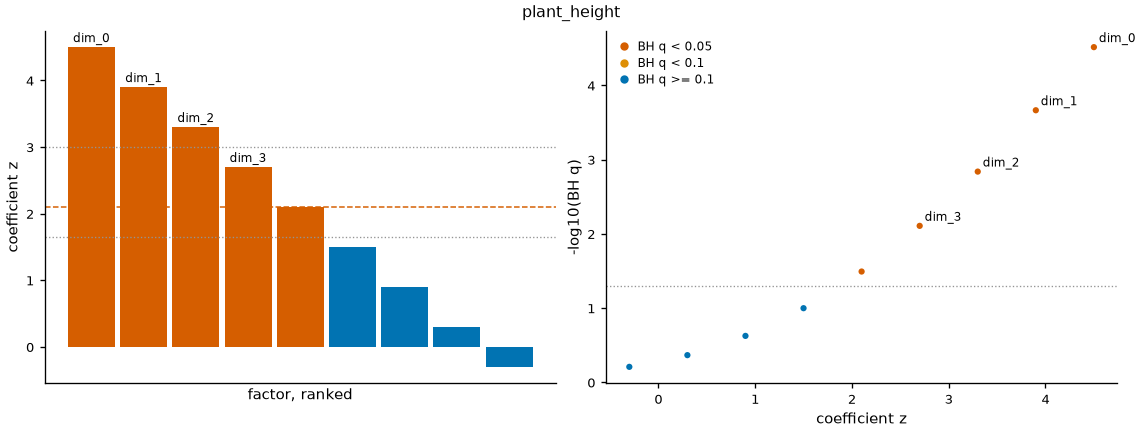

In [2]:
from scads_drvi.viz.enrichment import heritability_landscape

fig, (ax_bar, ax_vol) = heritability_landscape(
    interp.results,
    trait="plant_height",
    labels=interp.labels,
)
plt.show()
plt.close()

## 2. Trait concordance

Scatter of z-scores between two traits (left) and a histogram of their difference (right).
Useful for checking whether factors significant for one trait are also active for another.

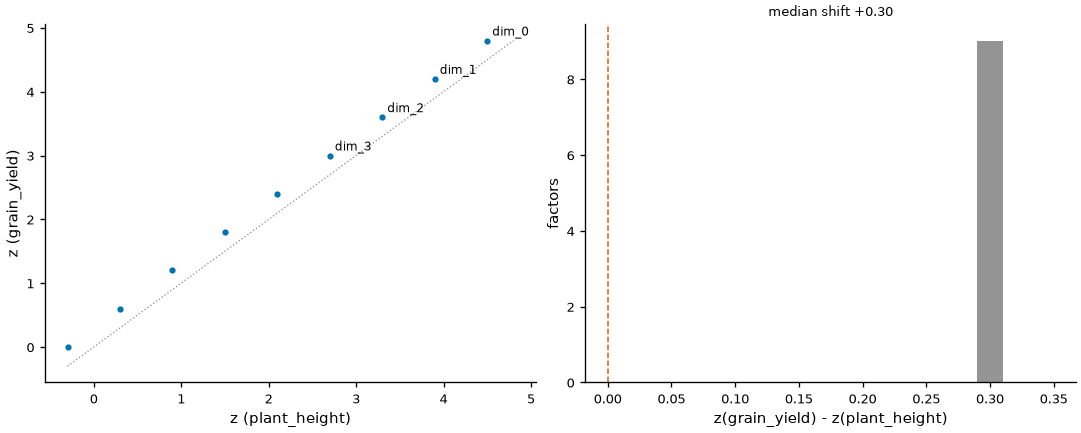

In [3]:
from scads_drvi.viz.enrichment import trait_concordance

fig, _ = trait_concordance(
    interp.results,
    traits=list(TRAITS),
    labels=interp.labels,
)
plt.show()
plt.close()

## 3. UMAP — categorical and continuous

Both functions accept an optional `ax` argument to embed into an existing figure.
Without it they create their own figure.

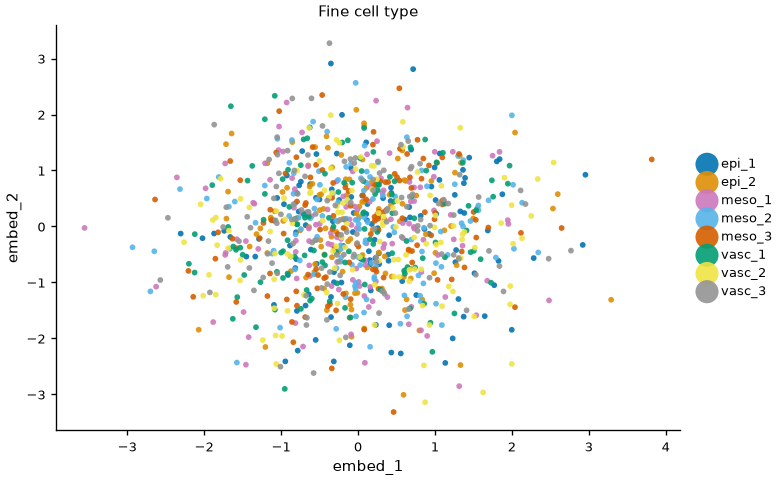

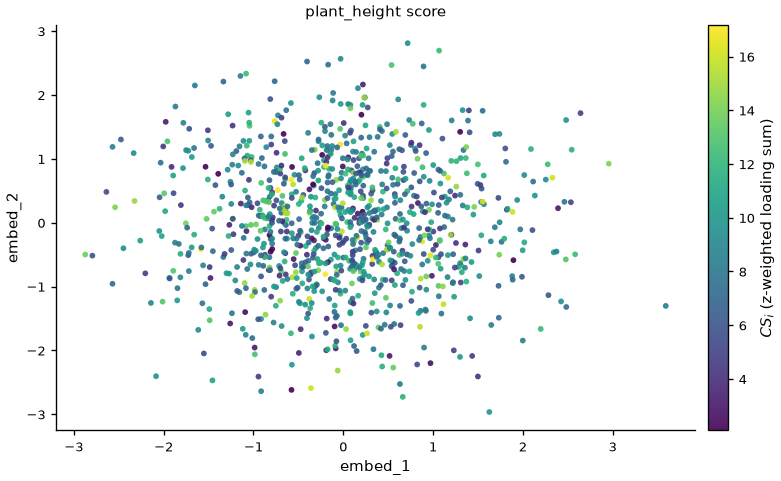

In [4]:
from scads_drvi.viz.umap import umap_categorical, umap_continuous

fig, ax = umap_categorical(cells, "fine_type", n=1000)
ax.set_title("Fine cell type")
plt.show()
plt.close()

fig, ax = umap_continuous(
    cells, "score",
    colorbar_label=scores.label,
    zero_as_background=True,
    n=1000,
)
ax.set_title("plant_height score")
plt.show()
plt.close()

## 4. Score by group — frugal box plot

`score_by_group` takes **pre-computed** `BoxStats`, not raw per-cell values.
This separation lets you control ordering, truncation, and highlighting before
committing to the figure.

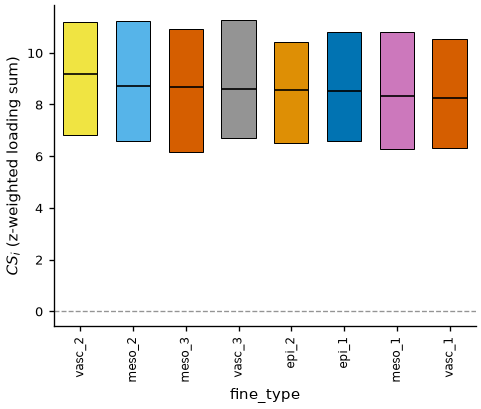

In [5]:
from scads_drvi.viz.frugal import box_stats
from scads_drvi.viz.enrichment import score_by_group

stats = box_stats(
    cells["score"],
    cells["fine_type"].astype(str),
    min_n=10,
    whis="quartile",
)
# Order groups by median descending, highlight the top vascular type
stats = stats.order_by("median", ascending=False)

fig, ax = score_by_group(
    stats,
    group_label="fine_type",
    value_label=scores.label,
    null=scores.null,
    highlight=["vasc_1"],
)
plt.show()
plt.close()

## 5. Grouped landscape — cell-type × tissue heatmap

`grouped_landscape` shows mean score for every (fine type, tissue) combination.
Bins below `min_cells` are masked with `masked_color` (grey by default).

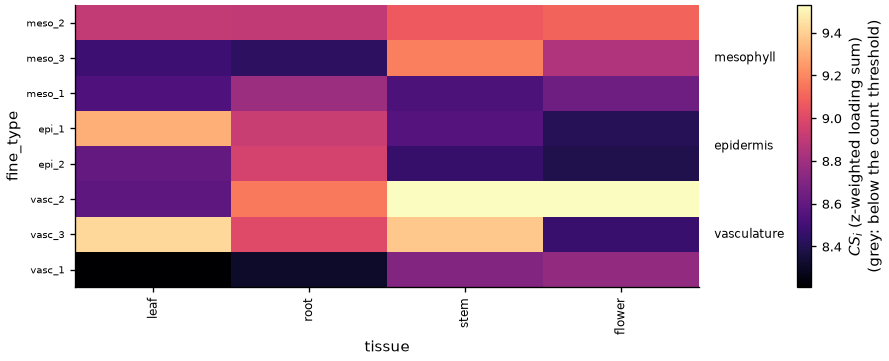

In [6]:
from scads_drvi.viz.enrichment import grouped_landscape
from scads_drvi.scores.aggregate import block_order

means, counts = group_matrix(
    scores.values, cells,
    index="fine_type", columns="tissue",
    min_cells=10, column_order=list(TISSUES),
)

# Compute block ordering so fine types stay within their lineage
blocked = summarize_by(scores.values, cells, by=["lineage", "fine_type"], min_cells=10)
order, spans = block_order(blocked, group="fine_type", block="lineage")

fig, ax = grouped_landscape(
    means.loc[order],
    counts.loc[order],
    row_label="fine_type",
    column_label="tissue",
    value_label=scores.label,
    blocks=spans,
)
plt.show()
plt.close()

## 6. Saving figures

`save_figure` writes to every format in a `SaveSpec` and returns the list of paths.
It also embeds provenance metadata (timestamp, software version) into the PDF.

In [7]:
from scads_drvi.viz.save import save_figure, SaveSpec, figure_metadata

outdir = root / "figures"
spec = SaveSpec(formats=("png", "pdf"), dpi={"png": 200, "pdf": 300}, close=True)
meta = figure_metadata(model=arm, trait="plant_height")

# Re-generate the landscape to save it
fig, _ = heritability_landscape(interp.results, trait="plant_height", labels=interp.labels)
paths = save_figure(fig, "01_landscape", outdir, spec=spec, metadata=meta)

for p in paths:
    print(p.name, f"  {p.stat().st_size:,} bytes")

01_landscape.png   52,951 bytes
01_landscape.pdf   17,098 bytes


## 7. Custom colour palettes

`categorical_palette` builds a stable category → colour map using the Wong (2011)
colourblind-safe palette for up to 8 categories, then samples from `turbo` for more.

In [8]:
from scads_drvi.viz.color import categorical_palette

palette = categorical_palette(
    list(fine),
    highlight="vasc_1",
    highlight_color="#D55E00",
)
print("vasc_1 colour:", palette["vasc_1"])
print("All colours:")
for cat, color in palette.items():
    print(f"  {cat:12s}: {color}")

vasc_1 colour: #D55E00
All colours:
  epi_1       : #0173B2
  epi_2       : #DE8F05
  meso_1      : #CC78BC
  meso_2      : #56B4E9
  meso_3      : #D55E00
  vasc_1      : #D55E00
  vasc_2      : #F0E442
  vasc_3      : #949494
